# GAN usage in DEGANN

### This notebook demonstrates how to create and train a GAN using DEGANN.

### Import necessary libraries:

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from degann.networks import IModel

from degann.networks.topology.densenet.topology_config import DenseNetParams
from degann.networks.topology.densenet.compile_config import DenseNetCompileParams
from degann.networks.topology.gan.topology_config import GANTopologyParams
from degann.networks.topology.gan.compile_config import GANCompileParams

2025-03-14 02:18:42.441763: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-14 02:18:42.455345: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-14 02:18:42.471346: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-14 02:18:42.471377: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-14 02:18:42.483012: I tensorflow/core/platform/cpu_feature_gua

### Prepare data for neural network training:

In [2]:
def sin10x(x):
    return np.sin(10 * x)


data_size = 2048
X = np.linspace(0, 1, int(data_size / 0.8)).reshape(-1, 1)
y = sin10x(X)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

### Define and create GAN architecture:

In [3]:
# Generates data with 1 input and 1 output
# Uses Leaky ReLU activation and has three hidden layers with 32 neurons each
gen_config = DenseNetParams(
    input_size=1,
    block_size=[32, 32, 32],
    output_size=1,
    activation_func="leaky_relu",
)

# Takes 2 inputs (generated input & output) and classifies validity
disc_config = DenseNetParams(
    input_size=2,  # (gen_input, gen_output)
    block_size=[32, 32, 32],
    output_size=1,
    activation_func="leaky_relu",
)

gan_params = GANTopologyParams(
    generator_params=gen_config,
    discriminator_params=disc_config,
)
gan = IModel(gan_params)

### Compile GAN:

In [4]:
gen_compile_config = DenseNetCompileParams(
    rate=0.0002,
    optimizer="Adam",
    loss_func="BinaryCrossentropy",
    metric_funcs=["mean_absolute_error"],
)
disc_compile_config = DenseNetCompileParams(
    rate=0.0002,
    optimizer="Adam",
    loss_func="BinaryCrossentropy",
    metric_funcs=["binary_accuracy"],
)
gan_compile_config = GANCompileParams(
    generator_params=gen_compile_config,
    discriminator_params=disc_compile_config,
)
gan.compile(gan_compile_config)

### Train GAN and log metrics to tensorboard:

In [5]:
log_dir = "./gan_usage_log"
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=0,
    embeddings_freq=0,
    update_freq="epoch",
)
gan.train(
    X_train,
    y_train,
    epochs=1500,
    mini_batch_size=64,
    callbacks=[tensorboard_callback],
)

Epoch 1/1500


I0000 00:00:1741943925.115198   95760 service.cc:145] XLA service 0x7f0b80004cc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1741943925.115337   95760 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6
W0000 00:00:1741943925.184172   95760 random_ops.cc:59] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. StatefulPartitionedCall/random_uniform/RandomUniform
2025-03-14 02:18:45.195201: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-03-14 02:18:45.581657: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.5000 - d_loss: 1.8517 - g_loss: 5.6455 - mean_absolute_error: 1.9957

I0000 00:00:1741943926.785911   95760 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - binary_accuracy: 0.5000 - d_loss: 1.8329 - g_loss: 5.5584 - mean_absolute_error: 1.9596
Epoch 2/1500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - binary_accuracy: 0.5000 - d_loss: 1.4971 - g_loss: 4.0461 - mean_absolute_error: 1.3312
Epoch 3/1500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.5000 - d_loss: 1.2325 - g_loss: 2.4565 - mean_absolute_error: 0.7919
Epoch 4/1500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.5000 - d_loss: 1.0496 - g_loss: 1.5776 - mean_absolute_error: 0.7200
Epoch 5/1500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.5000 - d_loss: 0.9166 - g_loss: 1.2677 - mean_absolute_error: 0.6939
Epoch 6/1500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.5000 - d_loss: 0.8211 - g_loss: 1.0730 - mean_absolute_error: 0.6826
Epoch 7/1500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.5000 - d_loss: 0.7626 - g_loss: 0.9479 - mean_absolute_error: 0.6804
Epoch 8/1500
32/3

### Evaluate GAN on test data:

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.5038 - d_loss: 0.6908 - g_loss: 0.7166 - mean_absolute_error: 0.0595  


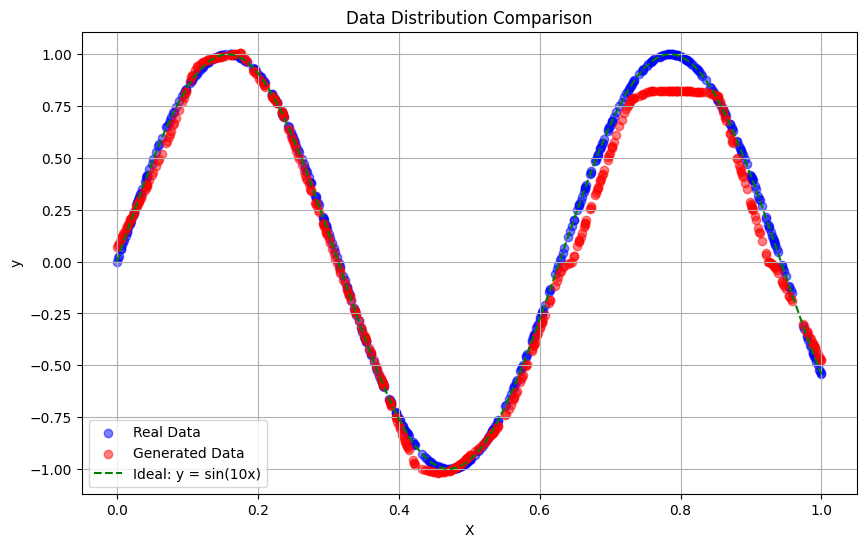

In [6]:
gan.evaluate(
    X_test,
    y_test,
    batch_size=64,
    callbacks=[tensorboard_callback],
)

plt.figure(figsize=(10, 6))

# Plot real data
plt.scatter(X_test, y_test, c="blue", label="Real Data", alpha=0.5)

# Plot generated data
plt.scatter(X_test, gan.feedforward(X_test), c="red", label="Generated Data", alpha=0.5)

# Plot ideal relationship
x = np.linspace(0, 1, 100)
plt.plot(x, sin10x(x), c="green", linestyle="--", label="Ideal: y = sin(10x)")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Data Distribution Comparison")
plt.legend()
plt.grid(True)
plt.show()